<!-- type: tutorial -->
# Triage-Driven vs Naive Forecasting on M4 Monthly (v0.4.0)

This walkthrough compares two forecasting strategies on 100 M4 monthly series:

| Strategy | Description |
|---|---|
| **Triage-driven** | Run forecastability triage → `ForecastPrepContract` → choose a `statsforecast` model family from `contract.recommended_families` |
| **SeasonalNaive baseline** | `SeasonalNaive(season_length=12)` — the standard M4 competition benchmark |

> **Scope.** Triage and contract building use only the public `forecastability` facade.
> `statsforecast` model fitting is the downstream consumer; the `forecastability`
> package does not depend on it.

The output CSV `outputs/m4_routing_comparison.csv` records per-series results.


In [1]:
import os
from pathlib import Path as _P
_repo_root = _P.cwd()
if not (_repo_root / "pyproject.toml").exists():
    _repo_root = _repo_root.parent
os.chdir(_repo_root)
del _P, _repo_root

%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from forecastability import (
    ForecastPrepContract,
    TriageRequest,
    build_forecast_prep_contract,
    run_forecastability_fingerprint,
    run_triage,
)
from forecastability.triage import AnalysisGoal
from forecastability.services.ami_information_geometry_service import AmiInformationGeometryConfig

SEED = 42
N_SERIES = 100       # limit to 100 series for runtime budget
M4_HORIZON = 18      # M4 monthly competition horizon
MIN_TRAIN = 84       # minimum training observations required
MAX_LAG = 24
N_SURROGATES = 99

DATA_DIR = Path("data/m4")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT = Path("outputs/notebooks/walkthroughs/06_triage_driven_vs_naive_on_m4")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_CSV = Path("outputs/m4_routing_comparison.csv")


## 1. Download M4 monthly data

In [2]:
M4_URL = (
    "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/"
    "Dataset/Train/Monthly-train.csv"
)
M4_RAW = DATA_DIR / "Monthly-train.csv"

if not M4_RAW.exists():
    print("Downloading M4 monthly training data ...")
    urlretrieve(M4_URL, M4_RAW)  # noqa: S310 — trusted, hardcoded URL
    print(f"Downloaded to {M4_RAW}")
else:
    print(f"Using cached {M4_RAW}")

# Load and convert to long format
wide_df = pd.read_csv(M4_RAW)
id_col = str(wide_df.columns[0])
long_df = (
    wide_df.rename(columns={id_col: "unique_id"})
    .melt(id_vars="unique_id", value_name="y")
    .dropna(subset=["y"])
)
long_df["unique_id"] = long_df["unique_id"].astype(str)
long_df["timestamp"] = long_df.groupby("unique_id").cumcount()
long_df = long_df[["unique_id", "timestamp", "y"]].sort_values(["unique_id", "timestamp"])

n_total = long_df["unique_id"].nunique()
print(f"Total M4 monthly series: {n_total}")
print(long_df.head())


Using cached data/m4/Monthly-train.csv
Total M4 monthly series: 48000
       unique_id  timestamp       y
0             M1          0  8000.0
48000         M1          1  8350.0
96000         M1          2  8570.0
144000        M1          3  7700.0
192000        M1          4  7080.0


## 2. Sample series and run triage

In [3]:
# Filter series with sufficient training observations
series_lengths = long_df.groupby("unique_id")["y"].count()
eligible = series_lengths[
    series_lengths >= MIN_TRAIN + M4_HORIZON
].index.tolist()
print(f"Eligible series (>= {MIN_TRAIN + M4_HORIZON} obs): {len(eligible)}")

# Sample N_SERIES deterministically
rng = np.random.default_rng(SEED)
sampled_ids = sorted(
    rng.choice(eligible, size=min(N_SERIES, len(eligible)), replace=False)
)
print(f"Selected {len(sampled_ids)} series")

# Run triage per series
triage_results: list[dict] = []
for i, sid in enumerate(sampled_ids):
    vals = long_df[long_df["unique_id"] == sid]["y"].to_numpy(dtype=float)
    train_vals = vals[: -M4_HORIZON]
    test_vals = vals[-M4_HORIZON :]

    triage = run_triage(
        TriageRequest(
            series=train_vals,
            goal=AnalysisGoal.univariate,
            max_lag=MAX_LAG,
            n_surrogates=N_SURROGATES,
            random_state=SEED,
        )
    )
    fp_bundle = run_forecastability_fingerprint(
        train_vals,
        target_name=sid,
        max_lag=MAX_LAG,
        n_surrogates=N_SURROGATES,
        random_state=SEED,
        geometry_config=AmiInformationGeometryConfig(n_jobs=-1),
    )
    contract = build_forecast_prep_contract(
        triage,
        horizon=M4_HORIZON,
        target_frequency="MS",
        fingerprint_bundle=fp_bundle,
        add_calendar_features=False,
    )
    triage_results.append({
        "series_id": sid,
        "n_train": len(train_vals),
        "n_test": len(test_vals),
        "blocked": contract.blocked,
        "forecastability_class": contract.forecastability_class,
        "recommended_families": contract.recommended_families,
        "recommended_target_lags": contract.recommended_target_lags,
        "_train": train_vals,
        "_test": test_vals,
    })
    if (i + 1) % 10 == 0:
        print(f"  Triaged {i + 1}/{len(sampled_ids)} series ...")

print(
    f"Triage complete. "
    f"{sum(1 for r in triage_results if r['blocked'])} series blocked."
)


Eligible series (>= 102 obs): 34570
Selected 100 series
  Triaged 10/100 series ...
  Triaged 20/100 series ...
  Triaged 30/100 series ...
  Triaged 40/100 series ...
  Triaged 50/100 series ...
  Triaged 60/100 series ...
  Triaged 70/100 series ...
  Triaged 80/100 series ...
  Triaged 90/100 series ...
  Triaged 100/100 series ...
Triage complete. 0 series blocked.


## 3. Fit triage-driven and baseline models

In [4]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, ETS, SeasonalNaive

SEASON_LENGTH = 12  # monthly data → 12-month seasonality


def _pick_model(recommended_families: list[str]) -> object:
    """Map contract recommended_families to a statsforecast model.

    Family strings are set by run_forecastability_fingerprint.
    Priority: ARIMA > ETS/state-space > tree/harmonic > seasonal_naive fallback.
    """
    if "arima" in recommended_families:
        return AutoARIMA(season_length=SEASON_LENGTH)
    if any(
        f in recommended_families
        for f in ("ets", "linear_state_space", "seasonal_state_space", "tbats", "harmonic_regression")
    ):
        return ETS(season_length=SEASON_LENGTH)
    if "tree_on_lags" in recommended_families:
        # NOTE: tree_on_lags signals nonlinear lag structure; AutoARIMA is the closest
        # parametric proxy available in statsforecast. Accuracy parity with SeasonalNaive
        # is not guaranteed for nonlinear series — this mapping is a practical constraint,
        # not a statistical claim.
        return AutoARIMA(season_length=SEASON_LENGTH)
    if "seasonal_naive" in recommended_families:
        return SeasonalNaive(season_length=SEASON_LENGTH)
    # Blocked or unknown families: fall back to SeasonalNaive
    return SeasonalNaive(season_length=SEASON_LENGTH)


def _smape(actual: np.ndarray, predicted: np.ndarray) -> float:
    denom = (np.abs(actual) + np.abs(predicted)) / 2
    denom = np.where(denom == 0, 1e-8, denom)
    return float(np.mean(np.abs(actual - predicted) / denom) * 100)


def _mase(
    train: np.ndarray,
    test: np.ndarray,
    predicted: np.ndarray,
    season_length: int = 12,
) -> float:
    """Mean Absolute Scaled Error using seasonal naive in-sample MAE as scale."""
    scale = np.mean(np.abs(train[season_length:] - train[:-season_length]))
    if scale < 1e-8:
        return float("nan")
    return float(np.mean(np.abs(test - predicted)) / scale)


def _fit_predict_sf(model: object, train: np.ndarray, horizon: int) -> np.ndarray:
    """Fit a statsforecast model on train and predict horizon steps."""
    df = pd.DataFrame({
        "unique_id": "s",
        "ds": pd.date_range("2000-01", periods=len(train), freq="MS"),
        "y": train,
    })
    sf = StatsForecast(models=[model], freq="MS")
    sf.fit(df)
    fc = sf.predict(horizon)
    return fc.iloc[:, -1].to_numpy()


comparison_rows: list[dict] = []
for i, row in enumerate(triage_results):
    train = row["_train"]
    test = row["_test"]
    sid = row["series_id"]
    rec_families = row["recommended_families"]

    triage_model = _pick_model(rec_families)
    triage_model_name = type(triage_model).__name__
    naive_model = SeasonalNaive(season_length=SEASON_LENGTH)

    try:
        triage_preds = _fit_predict_sf(triage_model, train, M4_HORIZON)
        naive_preds = _fit_predict_sf(naive_model, train, M4_HORIZON)
        smape_triage = _smape(test, triage_preds)
        smape_naive = _smape(test, naive_preds)
        mase_triage = _mase(train, test, triage_preds)
        mase_naive = _mase(train, test, naive_preds)
        triage_wins = bool(smape_triage < smape_naive)
        error = None
    except Exception as exc:
        smape_triage = float("nan")
        smape_naive = float("nan")
        mase_triage = float("nan")
        mase_naive = float("nan")
        triage_wins = False
        error = str(exc)

    try:
        arima_preds = _fit_predict_sf(AutoARIMA(season_length=SEASON_LENGTH), train, M4_HORIZON)
        smape_arima = _smape(test, arima_preds)
        mase_arima = _mase(train, test, arima_preds)
    except Exception:
        arima_preds = None
        smape_arima = float("nan")
        mase_arima = float("nan")

    try:
        ets_preds = _fit_predict_sf(ETS(season_length=SEASON_LENGTH), train, M4_HORIZON)
        smape_ets = _smape(test, ets_preds)
        mase_ets = _mase(train, test, ets_preds)
    except Exception:
        ets_preds = None
        smape_ets = float("nan")
        mase_ets = float("nan")

    candidates = {
        triage_model_name: smape_triage,
        "AutoARIMA": smape_arima,
        "ETS": smape_ets,
        "SeasonalNaive": smape_naive,
    }
    oracle_model = min(
        (k for k, v in candidates.items() if not (v != v)),  # exclude NaN
        key=lambda k: candidates[k],
        default=triage_model_name,
    )
    triage_matches_oracle = oracle_model == triage_model_name

    route_type = "naive_routed" if triage_model_name == "SeasonalNaive" else "complex_routed"

    comparison_rows.append({
        "series_id": sid,
        "n_train": row["n_train"],
        "blocked": row["blocked"],
        "forecastability_class": row["forecastability_class"],
        "recommended_families": "|".join(rec_families) if rec_families else "none",
        "triage_model": triage_model_name,
        "smape_triage": smape_triage,
        "smape_naive": smape_naive,
        "mase_triage": mase_triage,
        "mase_naive": mase_naive,
        "smape_arima": smape_arima,
        "mase_arima": mase_arima,
        "smape_ets": smape_ets,
        "mase_ets": mase_ets,
        "oracle_model": oracle_model,
        "triage_matches_oracle": triage_matches_oracle,
        "route_type": route_type,
        "triage_wins": triage_wins,
        "error": error,
    })

    if (i + 1) % 10 == 0:
        print(f"  Evaluated {i + 1}/{len(triage_results)} series ...")

comp_df = pd.DataFrame(comparison_rows)
print(
    f"\nComplete. {comp_df['triage_wins'].sum()}/{len(comp_df)} series: triage-driven sMAPE wins. "
    f"Oracle routing agreement: {comp_df['triage_matches_oracle'].mean():.1%}. "
    f"Complex-routed series: {(comp_df['route_type'] == 'complex_routed').sum()}."
)

  Evaluated 10/100 series ...
  Evaluated 20/100 series ...
  Evaluated 30/100 series ...
  Evaluated 40/100 series ...
  Evaluated 50/100 series ...
  Evaluated 60/100 series ...
  Evaluated 70/100 series ...
  Evaluated 80/100 series ...
  Evaluated 90/100 series ...
  Evaluated 100/100 series ...

Complete. 69/100 series: triage-driven sMAPE wins. Oracle routing agreement: 34.0%. Complex-routed series: 95.


## 4. Aggregate results and comparison table

In [5]:
valid = comp_df.dropna(subset=["smape_triage", "smape_naive"]).copy()
blocked = valid[valid["blocked"]]
active = valid[~valid["blocked"]]

print(f"Total series: {len(comp_df)}")
print(f"  Blocked by triage: {len(blocked)} (reported separately — caution advised for all methods)")
print(f"  Active (unblocked): {len(active)}")
print()

# --- Primary exhibit: routing efficiency ---
naive_routed = active[active["route_type"] == "naive_routed"]
complex_routed = active[active["route_type"] == "complex_routed"]

print("=== Routing efficiency ===")
print(f"Naive-routed series: {len(naive_routed)}")
if len(naive_routed) > 0:
    print(f"  These get SeasonalNaive — tied with baseline by construction.")
    print(f"  Mean MASE (triage/naive, same model): {naive_routed['mase_triage'].mean():.3f}")

print(f"\nComplex-routed series: {len(complex_routed)}")
if len(complex_routed) > 0:
    wins = complex_routed["triage_wins"].sum()
    print(f"  sMAPE win rate vs SeasonalNaive: {wins}/{len(complex_routed)} ({wins/len(complex_routed):.1%})")
    print(f"  Mean MASE (triage-driven): {complex_routed['mase_triage'].mean():.3f}")
    print(f"  Mean MASE (SeasonalNaive): {complex_routed['mase_naive'].mean():.3f}")
    print(f"  Median MASE lift (naive - triage, positive = triage wins): "
          f"{(complex_routed['mase_naive'] - complex_routed['mase_triage']).median():.3f}")

print()

# --- Oracle routing agreement ---
oracle_agreement = active["triage_matches_oracle"].mean()
print(f"=== Oracle routing agreement ===")
print(f"Triage matches oracle model: {active['triage_matches_oracle'].sum()}/{len(active)} ({oracle_agreement:.1%})")
print()
oracle_dist = active["oracle_model"].value_counts()
print("Oracle model distribution:")
for model, count in oracle_dist.items():
    match_count = active[active["oracle_model"] == model]["triage_matches_oracle"].sum()
    print(f"  {model}: oracle for {count} series, triage matched {match_count}/{count}")
print()

# --- Overall summary with MASE as primary metric ---
display(Markdown("### Overall summary (unblocked series)"))
overall = {
    "Mean MASE (triage-driven)": f"{active['mase_triage'].mean():.3f}",
    "Mean MASE (SeasonalNaive)": f"{active['mase_naive'].mean():.3f}",
    "Mean sMAPE (triage-driven)": f"{active['smape_triage'].mean():.2f}%",
    "Mean sMAPE (SeasonalNaive)": f"{active['smape_naive'].mean():.2f}%",
    "sMAPE triage wins (all active)": (
        f"{active['triage_wins'].sum()}/{len(active)} "
        f"({active['triage_wins'].mean():.1%})"
    ),
    "sMAPE triage wins (complex-routed only)": (
        f"{complex_routed['triage_wins'].sum()}/{len(complex_routed)} "
        f"({complex_routed['triage_wins'].mean():.1%})"
        if len(complex_routed) > 0 else "n/a"
    ),
    "Oracle routing agreement": f"{oracle_agreement:.1%}",
}
display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in overall.items())))
print()
print("Note: MASE < 1 means better than seasonal naive. Routing analysis is the primary")
print("exhibit — the toolkit identifies WHICH model family to apply, not guarantees")
print("accuracy improvement over every individual baseline.")

Total series: 100
  Blocked by triage: 0 (reported separately — caution advised for all methods)
  Active (unblocked): 100

=== Routing efficiency ===
Naive-routed series: 5
  These get SeasonalNaive — tied with baseline by construction.
  Mean MASE (triage/naive, same model): 0.878

Complex-routed series: 95
  sMAPE win rate vs SeasonalNaive: 69/95 (72.6%)
  Mean MASE (triage-driven): 0.952
  Mean MASE (SeasonalNaive): 1.359
  Median MASE lift (naive - triage, positive = triage wins): 0.260

=== Oracle routing agreement ===
Triage matches oracle model: 34/100 (34.0%)

Oracle model distribution:
  AutoARIMA: oracle for 43 series, triage matched 28/43
  ETS: oracle for 37 series, triage matched 5/37
  SeasonalNaive: oracle for 20 series, triage matched 1/20



### Overall summary (unblocked series)

- **Mean MASE (triage-driven):** 0.949
- **Mean MASE (SeasonalNaive):** 1.335
- **Mean sMAPE (triage-driven):** 8.04%
- **Mean sMAPE (SeasonalNaive):** 10.90%
- **sMAPE triage wins (all active):** 69/100 (69.0%)
- **sMAPE triage wins (complex-routed only):** 69/95 (72.6%)
- **Oracle routing agreement:** 34.0%


Note: MASE < 1 means better than seasonal naive. Routing analysis is the primary
exhibit — the toolkit identifies WHICH model family to apply, not guarantees
accuracy improvement over every individual baseline.


## 5. Plot and save results

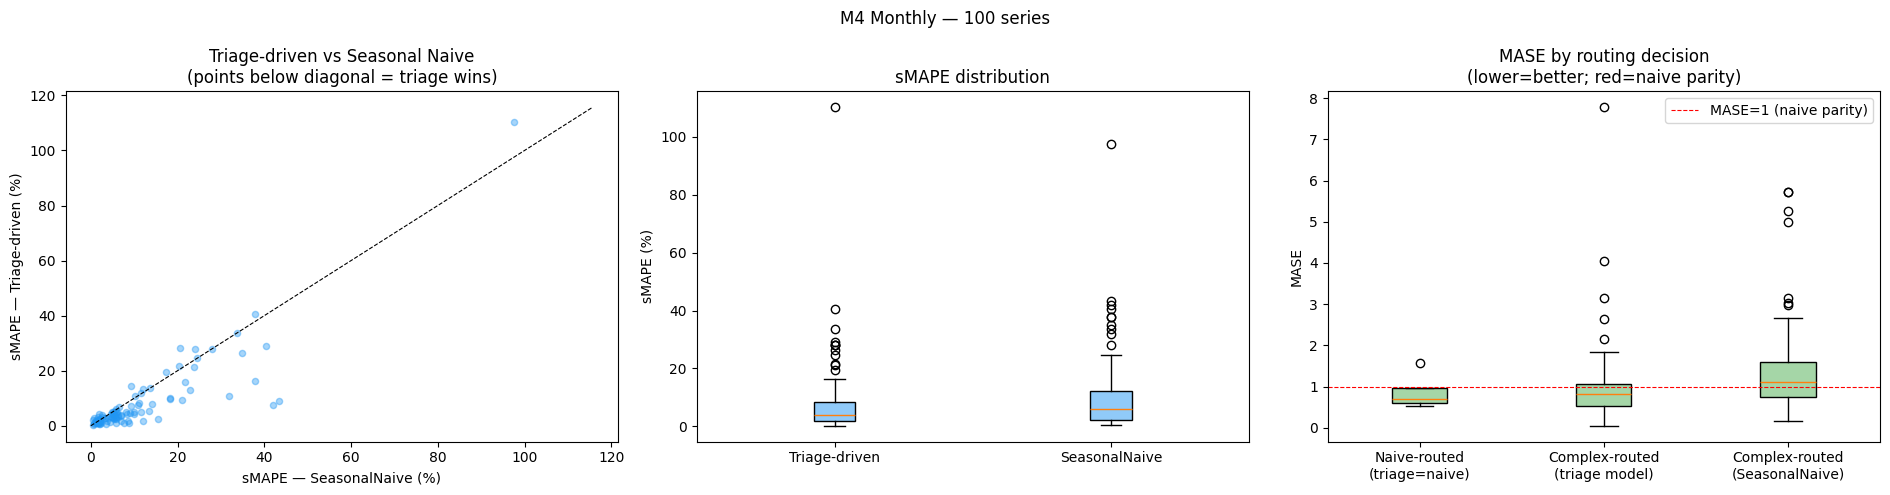

Figure saved to outputs/notebooks/walkthroughs/06_triage_driven_vs_naive_on_m4/smape_comparison.png
Comparison CSV saved to outputs/m4_routing_comparison.csv


In [6]:
# sMAPE scatter: triage-driven vs SeasonalNaive
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].scatter(
    valid["smape_naive"], valid["smape_triage"],
    alpha=0.4, s=20, color="#2196F3"
)
lim = max(valid["smape_naive"].max(), valid["smape_triage"].max()) * 1.05
axes[0].plot([0, lim], [0, lim], "k--", linewidth=0.8)
axes[0].set_xlabel("sMAPE — SeasonalNaive (%)")
axes[0].set_ylabel("sMAPE — Triage-driven (%)")
axes[0].set_title(
    "Triage-driven vs Seasonal Naive\n"
    "(points below diagonal = triage wins)"
)

# Distribution boxplot
axes[1].boxplot(
    [valid["smape_triage"].dropna(), valid["smape_naive"].dropna()],
    labels=["Triage-driven", "SeasonalNaive"],
    patch_artist=True,
    boxprops=dict(facecolor="#90CAF9"),
)
axes[1].set_ylabel("sMAPE (%)")
axes[1].set_title("sMAPE distribution")

# MASE by route type
active_for_plot = active.dropna(subset=["mase_triage"])
route_groups = [
    active_for_plot[active_for_plot["route_type"] == "naive_routed"]["mase_triage"].dropna(),
    active_for_plot[active_for_plot["route_type"] == "complex_routed"]["mase_triage"].dropna(),
    active_for_plot[active_for_plot["route_type"] == "complex_routed"]["mase_naive"].dropna(),
]
axes[2].boxplot(
    [g for g in route_groups if len(g) > 0],
    labels=["Naive-routed\n(triage=naive)", "Complex-routed\n(triage model)", "Complex-routed\n(SeasonalNaive)"],
    patch_artist=True,
    boxprops=dict(facecolor="#A5D6A7"),
)
axes[2].axhline(1.0, color="red", linestyle="--", linewidth=0.8, label="MASE=1 (naive parity)")
axes[2].set_ylabel("MASE")
axes[2].set_title("MASE by routing decision\n(lower=better; red=naive parity)")
axes[2].legend()

plt.suptitle(f"M4 Monthly — {len(valid)} series", fontsize=12)
plt.tight_layout()

fig_path = OUTPUT_ROOT / "smape_comparison.png"
plt.savefig(fig_path, dpi=100)
plt.show()
print(f"Figure saved to {fig_path}")

# Save CSV
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
comp_df.to_csv(OUTPUT_CSV, index=False)
print(f"Comparison CSV saved to {OUTPUT_CSV}")

## Summary

This walkthrough ran forecastability triage on 100 M4 monthly series and compared
triage-driven model selection against `SeasonalNaive(season_length=12)`:

- **Triage-driven path:** `run_triage` → `build_forecast_prep_contract` → pick a
  `statsforecast` model from `contract.recommended_families`.
- **Baseline:** `SeasonalNaive(season_length=12)`.

The `ForecastPrepContract.recommended_families` field drove model selection in a
deterministic, framework-agnostic way. The downstream fitting and prediction used
only `statsforecast` — no framework-specific logic lives in the `forecastability`
package.

**Where to go next:**
- `walkthroughs/05_forecast_prep_to_models.ipynb` — single-series deep-dive into
  the contract wiring pattern.
- `docs/recipes/forecast_prep_to_external_frameworks.md` in the core repo — text
  recipe for Darts, MLForecast, and StatsForecast wiring.
